**Build a network and plot the diagram**
This reproduces the urban network shown in Fig.56 with parameters from Table.36,36

In [1]:
# build a network and plot

from build_net import build_net_rural ,  net_visualize, build_net_suburban
net0 = build_net_suburban()


***NonEV overloading assessment***

Results goes to ./Results./nonEV.xlsx. It includes overlad_percent of the five types of transformer.

Use MATLAB to run Results.m to visualize it.

In [2]:
%run overload_assessment.py

running the year of 2015
running the year of 2020
running the year of 2025
running the year of 2030
running the year of 2035
running the year of 2040
running the year of 2045
running the year of 2050


***overloading assessment with EV***

Result goes to ./Result./withEV.xlsx

Visualize it with Results.m

In [3]:
%run main.py

running the year of 2015
running the year of 2020
running the year of 2025
running the year of 2030
running the year of 2035
running the year of 2040
running the year of 2045
running the year of 2050


In [95]:
import pandapower as pp
import numpy as np 
from build_net import build_net_2 ,  net_visualize, build_net_suburban, build_net_rural

net1 = build_net_suburban(1, res_num=1)
net1.bus['vm_pu']

KeyError: 'vm_pu'

In [91]:
#net_visualize(net1)
from pandapower.topology import unsupplied_buses
print(unsupplied_buses(net1))

set()


In [20]:
def calc_active_reactive_power(s_array, pf=0.95):
    total_active_power = np.sum(s_array*pf)
    total_reactive_power = np.sqrt(np.power(s_array, 2)- np.power(s_array*pf, 2)).sum()
    return total_active_power, total_reactive_power
    
        
    

In [25]:
s = np.array([0.3, 0.4])
print(calc_active_reactive_power(s))

(0.665, 0.2185749299439441)


### np.power(s, 2)

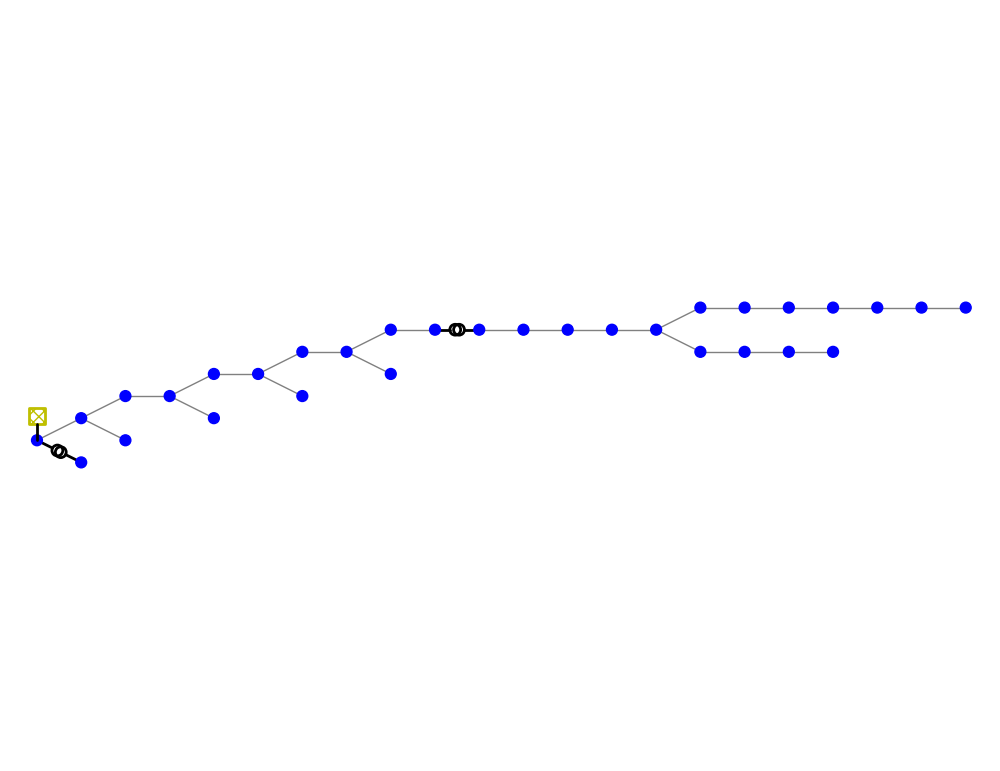

<Axes: >

In [3]:
pp.plotting.simple_plot(net1)

In [ ]:
# -*- coding: utf-8 -*-
"""
Created on Wed Dec 11 05:45:32 2024

@author: weixu
""" 


from matplotlib import pyplot as plt
import pandas as pd
import os

from overload_assessment import loading_assess 
from build_net import build_net_2  

def EV_growth(ev, rate):
    out={}
    for area , ev in EV_load.items():
        out[area] = ev* rate
    return out



'''
overloading assessment with EV loads

based on penetration rate

'''



EV_load0 = pd.read_excel('..\EV_profile_gen/EV_load_profiles_gen.xlsx')
# load profile of one charger; each charger assumed to serve one ev per day


penetrationRate = pd.read_excel('../EV_profile_gen/penetrationRate.xlsx').set_index('year' )


net0 = build_net_2()
bus_temp = net0.bus['zone']

total_res_bus = len(bus_temp[bus_temp=='Res']  )
total_comm_bus = len(bus_temp[bus_temp=='Comm'] )
total_public_bus = len(bus_temp[bus_temp=='Pub'] )




# nonEV energy consumption per day on the base year 2015
res = 0.48
comm=20
pub=6.8
grow_rate = 1.016**5
# fig = plt.figure(figsize=(10,15))
k=1
# k_ev =1
for year in range(2015, 2020,5):
    net = build_net_2()
    print('running the year of {}'.format(year))
    bus_load = {'Res':  res*k , 'Comm': comm*k, 'Pub': pub*k} #MWh per day
    k*= grow_rate
    
    
    
    ev_per_resbus = 15 *  2 *penetrationRate.loc[year, 'penetr'] /100
    charger_per_res_bus =  ev_per_resbus * 1   # assume one charger port per ev in residential area 
    
    # calculate total ev on a net, based on the num of residents
    total_ev =  ev_per_resbus * total_res_bus
    # work area charger ratio tab 20
    charger_per_comm_bus = total_ev * 60/1000    / total_comm_bus  
    
    # public area charger ratio tab 20
    charger_per_public_bus = total_ev * 40/1000 /  total_public_bus 
    
    
    
    
    
    
    EV_load={}
    
    # table 21: res area AC2 : AC1 = 12:3
    # assume AC2 serve 0.7 ev per day
    EV_load['Res'] = (EV_load0['home_AC2'] * 12/15 * .7 +  EV_load0['home_AC1']* 3/15 ) \
        *1e-3 *  charger_per_res_bus 
    
    # tab 21: work area AC2:AC1=13:5
    EV_load['Comm'] = (EV_load0['work_AC2'] *13/18 +  EV_load0['work_AC1'] *5/18 )    \
        *  charger_per_comm_bus*1e-3 
        
    # tab 21: pub area AC2:DC=9:3
    EV_load['Pub'] = ( EV_load0['public_AC2'] *9/12 +  EV_load0['public_DC'] * 3/12 ) \
        *1e-3 *    charger_per_public_bus
    
    
    ev_load = EV_load
    
    
    
    output_table =  loading_assess(net, bus_load ,ev_load )
    
    folder = './ResultsJan2/'
    os.makedirs(os.path.dirname(folder), exist_ok=True)
    output_table.to_excel('{}withEV{}.xlsx'.format(folder, year))
    
    





In [3]:
import pandas as pd 
import numpy as np 

data = pd.read_csv("./data/population_change_diff_areas.csv")


data_urban = data[data['area']=='urban']
change = np.array(data_urban['people_1000s'])/np.array(data_urban['people_1000s'].iloc[0])
change = np.concatenate([change, change, change])
data['rel_pop_change_frac'] = change
data

,Unnamed: 0,area,year,people_1000s,rel_pop_change_frac
0,0,urban,2023,40097.8,1.000000
1,1,urban,2024,41090.1,1.024747
2,2,urban,2025,41372.0,1.031777
3,3,urban,2026,41655.0,1.038835
4,4,urban,2027,41928.2,1.045648
...,...,...,...,...,...
79,79,rural,2046,50836.6,1.267815
80,80,rural,2047,51256.3,1.278282
81,81,rural,2048,51668.4,1.288559
82,82,rural,2049,52081.5,1.298862


In [81]:
import pandas as pd
ldev_load = pd.read_excel('./data/ldev_load_data/EV_load_profiles_gen.xlsx')

for colname in ldev_load.columns:
    ldev_load[colname] = ldev_load[colname]*10.29/ldev_load[colname].sum()


In [83]:
for c in ldev_load.columns:
    print(ldev_load[c].sum())

10.29
10.29
10.289999999999997
10.29
10.290000000000001
10.290000000000001
10.290000000000001
10.29
10.29


In [84]:
ldev_load.to_excel('./data/ldev_load_data/EV_load_profiles_daily_req.xlsx')

In [4]:
data.to_csv('./population_change_diff_areas.csv')

## Overload assessment 

In [80]:
# -*- coding: utf-8 -*-
"""
Created on Wed Dec 11 05:45:32 2024

@author: weixu & abhi
""" 


from matplotlib import pyplot as plt
import pandas as pd
import os

from overload_assessment import loading_assess 
from build_net import build_net_2 

def EV_growth(ev, rate):
    out={}
    for area , ev in EV_load.items():
        out[area] = ev* rate
    return out

def get_area_network(area_name):
    if area_name=='urban':
        return build_net_2()
    elif area_name=='suburban':
        return build_net_suburban() 
    elif area_name=='rural':
        return build_net_rural()
    else:
        raise NotImplementedError("Network not implemented")
'''
overloading assessment with EV loads
Based on:
    1. Change in population
    2. Penetration rate 
    3. Population distribution over housing 

'''

#####  Load the data ###### 

# Load profiles for different chargers and locations 
# load profile of one charger; each charger assumed to serve one ev per day

ev_load = pd.read_excel('./data/EV_load_profiles_gen.xlsx') 

pop_growth = pd.read_csv('./data/population_change_diff_areas.csv') #in fraction

penetration_rate = pd.read_csv('./data/penetration_rate_ldev.csv') #in percentage

charger_info = pd.read_excel("./data/chargers_for_1000_vehicles.xlsx")

pop_dist_acc_housing = pd.read_excel("./data/population_distribution_acc_house_types.xlsx") 

#######     xxx    #######

area_type = ['urban']

for area in area_type: 
    # build the network 
    net0 = get_area_network(area)
    bus_temp = net0.bus['zone']
    
    total_res_bus = len(bus_temp[bus_temp=='Res']  )
    total_comm_bus = len(bus_temp[bus_temp=='Comm'] )
    total_public_bus = len(bus_temp[bus_temp=='Pub'] )

    #get external data for given area type

    pop_growth_area = pop_growth[pop_growth['area']== area]
    pop_dist_acc_housing_area = pop_dist_acc_housing[pop_dist_acc_housing['area_type']==area]
    
    # nonEV energy consumption per day on the base year 2015
    res = 0.48
    comm=20
    pub=6.8
    grow_rate = 1.016**5
    k=1
        
    for year in range(2025, 2030,5):
        net = get_area_network(area)
        print('running the year of {}'.format(year))
        bus_load = {'Res':  res*k , 'Comm': comm*k, 'Pub': pub*k} #MWh per day
        k*= grow_rate

        # EV load: LDEV
        household_per_bus = 15
        vehicles_per_household = 2
        ldev_pen_rate = penetration_rate[
                            penetration_rate['year']==year
                                ]['penetration_rate'].item()
        pop_growth_rate = pop_growth_area[
                                pop_growth_area['year']==year
                                        ]['rel_pop_change_frac'].item()
        
        ev_per_resbus = household_per_bus * vehicles_per_household * pop_growth_rate * ldev_pen_rate /100 #

        l1_charger_per_res_bus = charger_info[charger_info['year']==year]['home_l1']*ev_per_resbus/1000 
        l2_charger_per_res_bus = charger_info[charger_info['year']==year]['home_l2']*ev_per_resbus/1000 

        # calculate EVs doing home vs public charging

        sfu_percent = pop_dist_acc_housing_area[
                                (pop_dist_acc_housing_area['year']==year) & \
                                (pop_dist_acc_housing_area['house_type']=='single_family_unit')
                                                ]['population_percent'].item()
        sfu_ev_ready_percent = pop_dist_acc_housing_area[
                                (pop_dist_acc_housing_area['year']==year) & \
                                (pop_dist_acc_housing_area['house_type']=='single_family_unit')
                                                ]['ev_ready_percent'].item()
        mfu_ev_ready_percent = pop_dist_acc_housing_area[
                            (pop_dist_acc_housing_area['year']==year) & \
                            (pop_dist_acc_housing_area['house_type']=='multi_family_unit')
                                            ]['ev_ready_percent'].item()
        
        ev_per_bus_sfu = ev_per_resbus * sfu_percent / 100
        ev_per_bus_mfu = ev_per_resbus * (100-sfu_percent) /100

        # 85% times people with home charging charge at home 
        ev_per_bus_sfu_res_charging = ev_per_bus_sfu * sfu_ev_ready_percent * 0.85 
        ev_per_bus_mfu_res_charging = ev_per_bus_mfu * mfu_ev_ready_percent * 0.85 

        ev_per_res_bus_res_charging = ev_per_bus_sfu_res_charging + ev_per_bus_mfu_res_charging

        # we assume residential EV charging is distributed 
        # between L1 and L2 according to the proportion of each type of charger available

        l1charger_fraction = (charger_info[charger_info['year']==year]['home_l1'] /  \
                                    (charger_info[charger_info['year']==year]['home_l1'] + \
                                             charger_info[charger_info['year']==year]['home_l2'])).item()
        
        ev_per_res_bus_res_charging_l1 = ev_per_res_bus_res_charging * l1charger_fraction
        ev_per_res_bus_res_charging_l2 = ev_per_res_bus_res_charging - ev_per_res_bus_res_charging_l1
        
        ev_per_res_bus_nonres_charging = ev_per_resbus - ev_per_res_bus_res_charging

        # calculate total ev on a net, based on the num of residents
        total_ev =  ev_per_resbus * total_res_bus
        total_ev_nonres_charging = ev_per_res_bus_nonres_charging * total_res_bus
        
        # work area chargers
        
        # no L1 work charger acc. to Dunsky
        l2_charger_per_comm_bus = charger_info[charger_info['year']==year]['work_l2']*total_ev/(1000 * total_comm_bus)
        
        
        # public area chargers
        dc_charger_per_pub_bus = charger_info[charger_info['year']==year]['public_dc']*total_ev/(1000 * total_public_bus) 
        l2_charger_per_pub_bus = charger_info[charger_info['year']==year]['public_l2']*total_ev/(1000 * total_public_bus) 

        # vehicles option for commercial or public charging are calculated proportional to available chargers 

        work_chargers = charger_info[charger_info['year']==year]['work_l2']
        pub_chargers = charger_info[charger_info['year']==year]['public_l2'] + charger_info[charger_info['year']==year]['public_dc']
        pub_chargers_dc_frac = charger_info[charger_info['year']==year]['public_dc']/pub_chargers

        ev_per_comm_bus = (total_ev_nonres_charging * (work_chargers/(work_chargers + pub_chargers)))/total_comm_bus
        
        ev_per_pub_bus = (total_ev_nonres_charging * (pub_chargers/(work_chargers + pub_chargers)))/total_public_bus
        ev_per_pub_bus_dc = ev_per_pub_bus * pub_chargers_dc_frac
        ev_per_pub_bus_l2 = ev_per_pub_bus - ev_per_pub_bus_dc
        
        ev_load_dict={}

        # adding the load to the buses 

        # residential charging 
        ev_load_dict['Res'] = (ev_load['home_AC2'] * ev_per_res_bus_res_charging_l2 + \
                                   ev_load['home_AC1'] * ev_per_res_bus_res_charging_l1) * 1e-3 # converting to MW


        # commercial/work charging
        # max 8 vehicles can be charged by one charger per day for L2
        ev_load_dict['Comm'] = ev_load['work_AC2'] * l2_charger_per_comm_bus * min(8, (ev_per_comm_bus/l2_charger_per_comm_bus).item()) * 1e-3


        # public charging
        # max 8 vehicles can be charged by one charger per day for L2 and 2 for L1

        ev_load_dict['Pub'] = (ev_load['public_AC2'] * l2_charger_per_pub_bus * min(8, (ev_per_pub_bus_l2/l2_charger_per_pub_bus).item()) + \
                           ev_load['public_AC1'] * dc_charger_per_pub_bus * min(2, (ev_per_pub_bus_dc/dc_charger_per_pub_bus).item())) * 1e-3

        

        
        # # table 21: res area AC2 : AC1 = 12:3
        # # assume AC2 serve 0.7 ev per day
        # EV_load['Res'] = (EV_load0['home_AC2'] * 12/15 * .7 +  EV_load0['home_AC1']* 3/15 ) \
        #     *1e-3 *  charger_per_res_bus 
        
        # # tab 21: work area AC2:AC1=13:5
        # EV_load['Comm'] = (EV_load0['work_AC2'] *13/18 +  EV_load0['work_AC1'] *5/18 )    \
        #     *  charger_per_comm_bus*1e-3 
            
        # # tab 21: pub area AC2:DC=9:3
        # EV_load['Pub'] = ( EV_load0['public_AC2'] *9/12 +  EV_load0['public_DC'] * 3/12 ) \
        #     *1e-3 *    charger_per_public_bus
        
        
        ev_load = EV_load
        
        
        
        output_table =  loading_assess(net, bus_load ,ev_load )
        
    folder = './results/ResultsJan3_mod1/'
    os.makedirs(os.path.dirname(folder), exist_ok=True)
    output_table.to_excel('{}withEV{}.xlsx'.format(folder, year))
    
    





running the year of 2025


KeyError: 'home_AC1'

In [92]:
ev_per_resbus = household_per_bus * vehicles_per_household * pop_growth_rate * ldev_pen_rate /100 #
ldev_pen_rate

3.18627451

In [29]:
EV_load = pd.read_excel('./data/EV_load_profiles_gen.xlsx') 

pop_growth = pd.read_csv('./data/population_change_diff_areas.csv') #in fraction

penetration_rate = pd.read_csv('./data/penetration_rate_ldev.csv') #in percentage

charger_info = pd.read_excel("./data/chargers_for_1000_vehicles.xlsx")

pop_dist_acc_housing = pd.read_excel("./data/population_distribution_acc_house_types.xlsx") 


In [65]:
year = 2025
pop_growth_area[pop_growth_area['year']==year ]['rel_pop_change_frac']

2    1.031777
Name: rel_pop_change_frac, dtype: float64

In [96]:
pop_dist_acc_housing_area = pop_dist_acc_housing[pop_dist_acc_housing['area_type']==area]
pop_dist_acc_housing_area

,area_type,house_type,population_percent,year,ev_ready_percent
0,urban,single_family_unit,58.7,2025,100
1,urban,multi_family_unit,41.3,2025,60
6,urban,single_family_unit,58.7,2030,100
7,urban,multi_family_unit,41.3,2030,29
12,urban,single_family_unit,58.7,2030,100
13,urban,multi_family_unit,41.3,2035,52
18,urban,single_family_unit,58.7,2035,100
19,urban,multi_family_unit,41.3,2040,54


In [54]:
year =  2030
l1charger_fraction = (charger_info[charger_info['year']==year]['home_l1'] /  \
                                    (charger_info[charger_info['year']==year]['home_l1'] + charger_info[charger_info['year']==year]['home_l2'])).item()

In [78]:
min(8, (ev_per_comm_bus/l2_charger_per_comm_bus).item())

-766.4950147912785

In [76]:
 (ev_per_comm_bus/l2_charger_per_comm_bus)

0   -766.495015
dtype: float64

In [77]:
ev_per_comm_bus

0   -961.084251
dtype: float64

## Plot results of different transformers and lines post power flow analysis


In [105]:
import glob 
import matplotlib.pyplot as plt 
import numpy as np 
import seaborn as sns 
import pandas as pd 
folder1 = "./results/Results_util_8hrs_suburban/"
type = 'tra'
res1_files =  glob.glob(f'{folder1}/*_{type}.xlsx')
res1_full = pd.DataFrame()

for year in range(2025, 2055, 5):
    res1_file = [fname for fname in res1_files if str(year) in fname][0]
    res_data1 = pd.read_excel(res1_file)
    res_data1['year'] = year
    res1_full = pd.concat([res1_full, res_data1], ignore_index=True)


### Line charts for loading of different transformers across different years

In [106]:


trafo_type = ['T1', 'T2', 'T3', 'T4', 'T5']
for t_type in trafo_type:
    res_part1 = res1_full[res1_full['T_type']==t_type]
    #res_part2 = res2_full[res2_full['T_type']=='T5']
    
    id_vars = {
               'line': ['Unnamed: 0', 'std_type', 'length_km' , 'max_i_ka', 'year'], 
              'tra' : ['Unnamed: 0', 'T_type', 'sn_mva', 'year']
              }
    
    
    res_part1_long = pd.melt(res_part1, 
                             id_vars=id_vars[type], 
                             value_vars=[str(i) for i in range(24)], 
                             var_name='hour',
                             value_name='loading percent(%)',
                            ignore_index=True)
    sns.set_style("whitegrid")  # Adds a basic grid
    lp = sns.lineplot(res_part1_long, x='hour', y='loading percent(%)',hue='year')
    lp.axhline(y=100, linewidth=2, color='red', ls=':')
    lp.get_figure().savefig(f'{folder1}/{type}_{t_type}.png')
    plt.close()


C:\Users\konar\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\konar\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\konar\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\konar\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating

### Barchart of number of overloaded transformers across years

In [10]:
load_arr = np.array(res1_full[res1_full.columns[3:-2]])
load_arr_overload = np.any(load_arr>100, axis=1)
res1_full['# transformers overloading'] = load_arr_overload
res1_part = res1_full[['year', 'T_type', '# transformers overloading']]
res_data_barplot = res1_part.groupby(['year', 'T_type'], as_index=False).sum()
res_data_barplot['year'] = res_data_barplot['year'].astype(str)
sns.set_style("whitegrid")  # Adds a basic grid

lp = sns.barplot(res_data_barplot, x='T_type', y='# transformers overloading', hue='year')
lp.get_figure().savefig(f'{folder1}/{type}_{t_type}_overload_barchart.png')
plt.close()

## Compare individual loads across years and transformers

In [155]:
folder = "./results/Results_Jan15_v3urban"
ldev_load_files = glob.glob(f'{folder}/*_ldev_load*')
mhdev_load_files = glob.glob(f'{folder}/*_mhdev_load*')

def combine_dfs_from_fnames(fnamelist):
    df = pd.DataFrame()
    for f in fnamelist:
        year_data = pd.read_csv(f)
        year_data['year'] = int(f.split('\\')[1].split('_')[0])
        year_data['vehicle_type'] = f.split('\\')[1].split('_')[1]
        df = pd.concat([df, year_data])
    return df

C:\Users\konar\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\konar\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: >

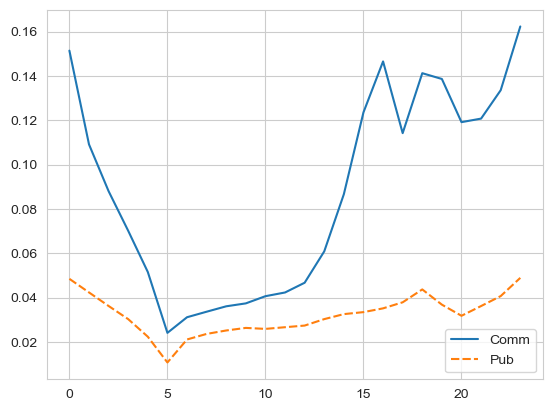

In [156]:
ldev_load_data = combine_dfs_from_fnames(ldev_load_files)
mhdev_load_data = combine_dfs_from_fnames(mhdev_load_files)
ev_load_data = pd.concat([ldev_load_data, mhdev_load_data])
sns.lineplot(mhdev_load_data[mhdev_load_data['year']==2050].drop(columns=['Unnamed: 0', 'year']))

### res_full_long = pd.melt(res1_full, 
                             id_vars=id_vars[type], 
                             value_vars=[str(i) for i in range(24)], 
                             var_name='hour',
                             value_name='loading percent(%)',
                            ignore_index=True)

val  = res_full_long[res_full_long['loading percent(%)'] > 100].groupby(['year', 'T_type', 'Unnamed: 0']).count()

In [143]:
val.iloc[24]

sn_mva                10
hour                  10
loading percent(%)    10
Name: (2030, T4, 307), dtype: int64

In [25]:

res_part2_long = pd.melt(res_part2, 
                         id_vars=id_vars[type], 
                         value_vars=[str(i) for i in range(24)], 
                         var_name='hour',
                         value_name='overload',
                        ignore_index=True)
sns.lineplot(res_part2_long, x='hour', y='overload',hue='year')
sns.set_style("whitegrid")  # Adds a basic grid

NameError: name 'res_part2' is not defined

# Modelling MHDEV for representative network

## Building arrival rate: Depot

In [208]:
import pandas as pd 
import numpy as np 
import glob
import seaborn as sns
import matplotlib.pyplot as plt

depot_charging_data_folder = './data/fleet_dna/'

f_names = glob.glob(f'{depot_charging_data_folder}/*.csv')

full_data = pd.DataFrame()
for f in f_names:
    data = pd.read_csv(f)[['vid', 'class_id', 'end_ts']]
    data_end_hr = data['end_ts'].str.split(' ').str[1].str.split(':').str[0]
    data_end_min = data['end_ts'].str.split(' ').str[1].str.split(':').str[1]
    data_end_time = ((data_end_hr.astype(int)*60+data_end_min.astype(int))/15).astype(int)
    data['end_time'] = data_end_time
    full_data = pd.concat([full_data, data])
    

In [ ]:
pd.options.mode.copy_on_write = False
mdev_data = full_data[full_data['class_id'].isin([3,4,5,6])]
hdev_data = full_data[full_data['class_id'].isin([7, 8 ])]
full_data['class_name'] = ''

full_data.loc[full_data['class_id'].isin([3,4,5,6]), 'class_name'] = 'mdev'
full_data.loc[full_data['class_id'].isin([7, 8 ]), 'class_name'] = 'hdev'


sns.histplot(full_data, x = 'end_time', discrete=True, hue='class_name')



In [204]:
arrival_rate_data = pd.DataFrame(columns = ['class_name', '15_min_block', 'arrival_rate'])
arrival_rate_data['class_name'] = ['mdev']*96 + ['hdev']*96
arrival_rate_data['15_min_block'] = np.concatenate([np.arange(96), np.arange(96)], 0 )
mdev_data_arr_count, bins = np.histogram(np.array(full_data[full_data['class_name']=='mdev']['end_time']), bins=96)
hdev_data_arr_count, bins = np.histogram(np.array(full_data[full_data['class_name']=='hdev']['end_time']), bins=96)
mdev_data_arr_count = mdev_data_arr_count/mdev_data_arr_count.sum()
hdev_data_arr_count = hdev_data_arr_count/hdev_data_arr_count.sum()
arrival_rate_data['arrival_rate'] = np.concatenate([mdev_data_arr_count, hdev_data_arr_count], axis=0)


In [ ]:
sns.lineplot(arrival_rate_data, x='15_min_block', y='arrival_rate', hue='class_name')
#arrival_rate_data.to_csv('./mhdev_arrival_rate.csv')

## Building arrival rate: Opportunity

In [302]:
f_path = '../data/formatted_data/mhdev_opportunity_charging_behavior.csv'
opp_charge_info = pd.read_csv(f_path)
opp_charge_info = opp_charge_info.loc[opp_charge_info['Max Power']> 100]
arrival_rate_opp = pd.DataFrame(columns = ['class_name', '15_min_block', 'arrival_rate'])
opp_charge_info['15_min_block'] = (opp_charge_info['Charge Start Time_mins']/15).astype(int)
hist_arr, bins = np.histogram(np.array(opp_charge_info['15_min_block']), bins=np.arange(97), density=True)
arrival_rate_opp['class_name'] = ['mdev']*96 + ['hdev']*96
arrival_rate_opp['15_min_block'] = np.concatenate([np.arange(96), np.arange(96)], axis=0)
arrival_rate_opp['arrival_rate'] = np.concatenate([hist_arr, hist_arr], axis=0)

arrival_rate_opp.to_csv('./mhdev_opportunity_arrival_rate.csv')

In [40]:
arrival_rate_opp = pd.read_csv('./mhdev_opportunity_arrival_rate.csv')

FileNotFoundError: [Errno 2] No such file or directory: './mhdev_opportunity_arrival_rate.csv'

C:\Users\konar\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\konar\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='15_min_block', ylabel='arrival_rate'>

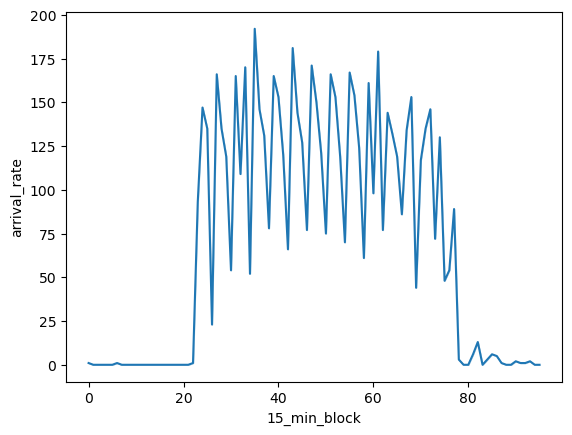

In [300]:
sns.lineplot(arrival_rate_opp, x='15_min_block', y='arrival_rate')

## Build Load profile using arrival rate

In [605]:
import math 

def build_charge_kernel(charge_rate_per_hr, energy_required, timesteps=96):
    charge_arr = np.zeros(timesteps)
    end_timestep = math.floor(energy_required/charge_rate_per_hr*(timesteps/24))
    charge_arr[0:end_timestep] = charge_rate_per_hr/(timesteps/24)

    #add the extra bit to the last timestep
    if energy_required%charge_rate_per_hr*(timesteps/24)!=0:
        charge_arr[end_timestep] = energy_required-(charge_rate_per_hr/(timesteps/24)*end_timestep)
    return charge_arr

def conv_ev_load(arrival_rate, charge_kernel, timesteps=24):
    arr_len = len(arrival_rate)
    if arr_len%timesteps!=0:
        print("The subsampling should be perfectly divisible")
    conv_data = np.convolve(charge_kernel, arrival_rate, mode='full')
    conv_data[0:arr_len-1] = conv_data[0:arr_len-1]+conv_data[arr_len:]
    conv_data_new = conv_data[0:arr_len]
    print(conv_data_new.sum())
    conv_data_reshape = conv_data_new.reshape(timesteps, int(arr_len/timesteps), ).sum(axis=1)
    return conv_data_reshape
    

In [607]:
# build the load profile for each charger and vehicle type
depot_arrival_rate = pd.read_csv('./data/mhdev_load_data/mhdev_depot_arrival_rate.csv')
opp_arrival_rate = pd.read_csv('./data/mhdev_load_data/mhdev_opportunity_arrival_rate.csv')

daily_energy_req = {'mdev': 53.3, 'hdev': 298.6}
charger_rated_powers = {'depot_l3': 50, 'opp_fast': 350}

for v_type, eng_reqired in daily_energy_req.items():
    load_profiles = pd.DataFrame()
    print('eng', eng_reqired)
    for c_type, rated_pow in charger_rated_powers.items():
        charge_kernel = build_charge_kernel(rated_pow, eng_reqired)
        print('ck', charge_kernel.sum())
        if c_type=='depot_l3':
            arrival_rate = np.array(depot_arrival_rate[depot_arrival_rate['class_name']==v_type]['arrival_rate'])
        if c_type=='opp_fast':
            arrival_rate = np.array(opp_arrival_rate[opp_arrival_rate['class_name']==v_type]['arrival_rate'])

        ev_load = conv_ev_load(arrival_rate, charge_kernel)
        load_profiles[c_type] = ev_load
        load_profiles.to_csv(f'./data/{v_type}_load_profiles.csv', index=False)


eng 53.3
ck 53.3
53.299999999999756
ck 53.3
53.29999999999983
eng 298.6
ck 298.6
298.59999999999866
ck 298.6
298.5999999999991


C:\Users\konar\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\konar\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: >

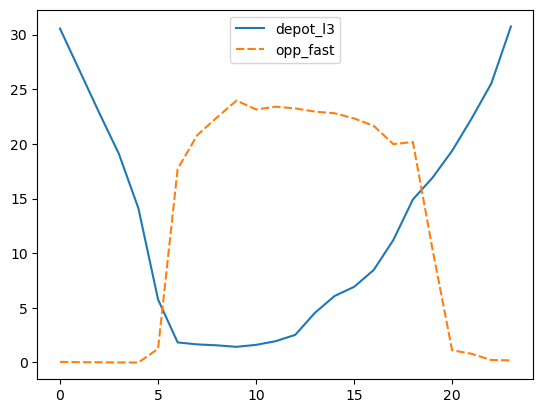

In [623]:
mdev_lp = pd.read_csv('./data/mhdev_load_data/hdev_load_profiles.csv')
sns.lineplot(mdev_lp)

## Vehicle number for representative networks 

In [527]:
total_vehicle_numbers = pd.read_excel('./data/mhdev_load_data/mhdev_numbers_pan_canada.xlsx')
vehicle_numbers = pd.DataFrame(columns=['year', 'area', 'mdev', 'hdev'])
canada_pop_2025 = 41372200
pop = {
       'urban' : 630*6*2.5,
       'suburban' : 1890*6*2.5,
       'rural': 2512*2.5
      }

for area, pop_val in pop.items():
    part_data = pd.DataFrame(columns=['year', 'area', 'mdev', 'hdev'])
    mdev_numbers = np.array(total_vehicle_numbers['mdev']) * (pop_val / canada_pop_2025)
    hdev_numbers = np.array(total_vehicle_numbers['hdev']) * (pop_val / canada_pop_2025)
    part_data['year'] = np.arange(2025, 2055, 5)
    part_data['area'] = [area] * len(np.arange(2025, 2055, 5))
    part_data['mdev'] = mdev_numbers
    part_data['hdev'] = hdev_numbers
    vehicle_numbers = pd.concat([vehicle_numbers, part_data])

vehicle_numbers.to_csv('./data/mhdev_load_data/mhdev_numbers_across_diff_areas.csv')

C:\Users\konar\AppData\Local\Temp\ipykernel_27612\1040122321.py:18: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  vehicle_numbers = pd.concat([vehicle_numbers, part_data])


## Charger numbers across different representative networks 

In [408]:
bev_to_port_ratio = pd.read_excel('./data/mhdev_load_data/vehicle_to_port_ratio.xlsx')
charger_numbers = pd.DataFrame()
#public_l3_to_fast = 54/46
#private_l3_to_fast = 89/11
public_l3_frac = 0.54
private_l3_frac = 0.89
for area in ['urban', 'suburban', 'rural']:
    
    charger_num_area = pd.DataFrame(columns=['year', 'area', 'public_l3', 'private_l3', 'public_fast', 'private_fast'])
    vehicle_num = np.array(vehicle_numbers.loc[vehicle_numbers['area']==area , :]['mdev']) + \
                        np.array(vehicle_numbers.loc[vehicle_numbers['area']==area , :]['hdev'])

    
    public_chargers = vehicle_num/np.array(bev_to_port_ratio['public'])
    public_l3 = public_chargers*public_l3_frac
    public_fast = public_chargers-public_l3

    private_chargers = vehicle_num/np.array(bev_to_port_ratio['private'])
    private_l3 = private_chargers*private_l3_frac
    private_fast = private_chargers-private_l3
    
    charger_num_area['year'] = np.arange(2025,2055,5)
    charger_num_area['area'] = [area]*len(np.arange(2025,2055,5))
    charger_num_area['public_l3'] = public_l3
    charger_num_area['public_fast'] = public_fast
    charger_num_area['private_l3'] = private_l3
    charger_num_area['private_fast'] = private_fast
    
    charger_numbers = pd.concat([charger_num_area, charger_numbers])

charger_numbers.to_csv('./data/mhdev_load_data/charger_numbers_across_networks_and_years.csv')

In [2]:
vehicles_per_charger = {'public' : 3.2, 'private': 1.2 }

NameError: name 'bev_to_port_ratio' is not defined

## Visualizing results and intermediate data

In [702]:
mhdev_load_files = glob.glob('./results/ResultsJan10_v8_suburban/other_info/*_mhdev_load.csv')
ldev_load_files = glob.glob('./results/ResultsJan10_v8_suburban/other_info/*_ldev_load.csv')

ev_num_files = glob.glob('./results/ResultsJan10_v8_suburban/other_info/*_ev_numbers.csv')
ch_num_files = glob.glob('./results/ResultsJan10_v8_suburban/other_info/*_chargers_numbers.csv')

In [703]:
ldev_load_full_data = pd.DataFrame()
mhdev_load_full_data = pd.DataFrame()

ev_full_data = pd.DataFrame()
ch_full_data = pd.DataFrame()

for fname in ch_num_files:
    data = pd.read_csv(fname)
    data['year'] = fname.split('\\')[-1].split('_')[0]
    data['ev_type'] = fname.split('\\')[-1].split('_')[1]
    ch_full_data = pd.concat([ch_full_data, data])


for fname in ev_num_files:
    data = pd.read_csv(fname)
    data['year'] = fname.split('\\')[-1].split('_')[0]
    data['ev_type'] = fname.split('\\')[-1].split('_')[1]
    ev_full_data = pd.concat([ev_full_data, data])


for fname in ldev_load_files:
    data = pd.read_csv(fname)
    data['year'] = fname.split('\\')[-1].split('_')[0]
    data['ev_type'] = fname.split('\\')[-1].split('_')[1]
    ldev_load_full_data = pd.concat([ldev_load_full_data, data])

for fname in mhdev_load_files:
    data = pd.read_csv(fname)
    data['year'] = fname.split('\\')[-1].split('_')[0]
    data['ev_type'] = fname.split('\\')[-1].split('_')[1]
    mhdev_load_full_data = pd.concat([mhdev_load_full_data, data])

In [704]:
load_full_data = pd.concat([mhdev_load_full_data, ldev_load_full_data])

C:\Users\konar\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\konar\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: >

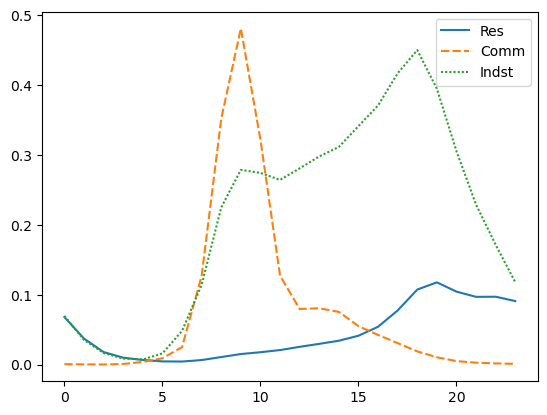

In [718]:
sns.lineplot(ldev_load_full_data[ldev_load_full_data['year']=='2050'].drop(columns=['Unnamed: 0']))

In [ ]:
sns.lineplot(mhdev_load_full_data[mhdev_load_full_data['year']=='2050'].drop(columns=['Unnamed: 0']))

C:\Users\konar\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\konar\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: >

In [1]:
ev_rel_data = pd.DataFrame()
ev_rel_data['ev_in_comm_zone'] = ev_full_data['ev_per_comm_bus']*6
ev_rel_data['ev_in_pub_zone_dc'] = (ev_full_data['ev_per_pub_bus_l2'] + ev_full_data['ev_per_pub_bus_dc'])*24 

ev_rel_data['mhdev_in_comm_zone'] = ev_full_data['mdev_in_comm_zone_charger_tput'] + ev_full_data['hdev_in_comm_zone_charger_tput']
ev_rel_data['mhdev_in_pub_zone'] = ev_full_data['mdev_in_pub_zone_charger_tput'] + ev_full_data['hdev_in_pub_zone_charger_tput']

ev_rel_data

NameError: name 'pd' is not defined

In [ ]:
sns.lineplot(ch_full_data.reset_index().drop(columns=['index']))

## Province wise load extrapolation

In [2]:
import numpy as np 
import pandas as pd
import glob

rep_urban_pop = 9450
rep_rural_pop = 6280
rep_suburban_pop = 28350
rep_area_pop = {'urban': 9450, 'suburban': 28350, 'rural': 6280}

canada_pop = {'urban' : [2922179,
                    1563021,
                    1038785,
                    863690,
                    236605,
                    186811,
                    138862,
                    97911,
                    74502,
                    17836,
                    5852,
                    5783,
                    4308,
                    ],
'suburban': [11688717, 
                    6252082,
                    4155139,
                    3454760,
                    946418,
                    747244,
                    555446,
                    391646,
                    298005,
                    71346,
                    23406,
                    23132,
                    17232,
                    ],
'rural' : [2011334,
                    1738395,
                    675266,
                    693924,
                    359245,
                    394010,
                    419553,
                    410100,
                    227264,
                    82181,
                    13582,
                    13925,
                    21301,
                    ]
}
nonev_load_dict = {
                   'urban' : {'Res': 0.73, 'Comm': 23, 'Pub': 6.8},
                   'suburban': {'Res': 0.73, 'Comm': 11.65, 'Indst': 11.07}
              }

load_multiplier = {'urban' : {'Res': 252, 'Comm': 6, 'Pub': 24}, 
                  'suburban': {'Res': 756, 'Comm': 18, 'Indst': 18},
                  'rural': {'Res' : 1}}

In [54]:
year = 2040

#for urban network
base_folders = {'urban': './results/Results_util_16hrs_urban', 
                'suburban': './results/Results_util_16hrs_suburban',
                'rural': './results/Results_rural_20Jan/other_info'}


In [67]:
area_load = {'urban': {'Res': 0, 'Comm': 0, 'Pub': 0}, 
             'suburban': {'Res': 0, 'Comm': 0, 'Indst': 0},
             'rural': 0}
year = 2050
for area, base_folder in base_folders.items():
    fnames = glob.glob(f'{base_folder}/{year}*load.csv')
    
    data_full = pd.DataFrame()
    for fname in fnames:
        data = pd.read_csv(fname)
        if 'ldev' in fname:
            pass
            data['vehicle_type'] = 'ldev'
            data_full = pd.concat([data_full, data])

        if 'mhdev' in fname:
            #pass
            data['vehicle_type'] = 'mhdev'
            data_full = pd.concat([data_full, data])


    if area=='rural':
        colnames = data_full.columns
        for col in colnames:
            if 'bus' in col:
                area_load[area] += data_full[col].sum()
        area_load[area] = area_load[area]*1*sum(canada_pop[area])/rep_area_pop[area]*365/(1000*1000)
    else:    
        for key in load_multiplier[area].keys():
            rep_network_load = data_full[key].sum()*load_multiplier[area][key]
            #print(f'{area} -> {key} : {rep_network_load}')
            area_load[area][key]+=rep_network_load*sum(canada_pop[area])/rep_area_pop[area]*365/(1000*1000)
            

In [68]:
area_load

{'urban': {'Res': 19.381073927597363,
  'Comm': 6.4481866917220145,
  'Pub': 13.163396171821066},
 'suburban': {'Res': 84.74438420410286,
  'Comm': 22.1875667698781,
  'Indst': 42.83640653349134},
 'rural': 21.213281174399995}

In [74]:
area = 'suburban'
sum(canada_pop[area])/rep_area_pop[area]

1009.685114638448

In [29]:
for area in ['urban', 'suburban', 'rural']:
    print(sum(canada_pop[area])/1000000)

7.156145
28.624573
7.06008
